# 1. Purpose

This notebook brings together the final frozen outputs from the kidney-transplant machine-unlearning experiments for dissertation reporting. It performs **no model training** and **no unlearning**. Existing experimental outputs are treated as frozen; the work here is limited to loading, validation, transparent aggregation, comparison, and visualisation.

The main MLP comparison covers **Full Retraining**, **Retain-Set Fine-Tuning**, **Gradient Ascent**, and **Gradient Difference** across Recipient Withdrawal, Donor Withdrawal, Hospital Removal, Invalid Consent, and Retention Expiry. Full Retraining is the behavioural and runtime reference; the other three are approximate methods.

In [1]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.stats import ks_2samp
from IPython.display import Markdown, display

pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 140)
warnings.filterwarnings('ignore', category=UserWarning, module='matplotlib')

# Find the repository root without depending on the notebook launch directory.
candidates = [Path.cwd(), *Path.cwd().parents]
PROJECT_ROOT = next((p for p in candidates if (p / 'code/final_submission/results').is_dir()), None)
if PROJECT_ROOT is None:
    raise FileNotFoundError('Could not locate code/final_submission/results from the current directory.')
RESULTS_ROOT = PROJECT_ROOT / 'code/final_submission/results'
FIGURE_DIR = RESULTS_ROOT / 'paper_figures'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TRAINING_PERFORMED = False
print(f'Frozen results: {RESULTS_ROOT}')
print(f'Paper figures: {FIGURE_DIR}')

Frozen results: /Users/niamhhughes/Desktop/Desktop - Niamh’s MacBook Pro/QUB/Research Proj/code/final_submission/results
Paper figures: /Users/niamhhughes/Desktop/Desktop - Niamh’s MacBook Pro/QUB/Research Proj/code/final_submission/results/paper_figures


# 2. Load Final Experimental Results

Only canonical files inside `code/final_submission/results` are considered. Historical Adult Income, CastMe, and older LLM run directories are outside this scope.

## 2.1 Locate Result Files

The manifest below records every file used in the main comparison and identifies its experimental source. Each file must be found exactly once.

In [2]:
METHOD_ROOTS = {
    'Full Retraining': RESULTS_ROOT / 'full_retraining',
    'Retain-Set Fine-Tuning': RESULTS_ROOT / 'retain_set_fine_tuning',
    'Gradient Ascent': RESULTS_ROOT / 'gradient_ascent',
    'Gradient Difference': RESULTS_ROOT / 'gradient_difference',
}
SOURCE_NOTEBOOKS = {
    'Full Retraining': '02_full_retraining.ipynb',
    'Retain-Set Fine-Tuning': '03_retain_set_fine_tuning.ipynb',
    'Gradient Ascent': '04_gradient_ascent.ipynb',
    'Gradient Difference': '06_gradient_difference.ipynb',
}

def locate_one(method, result_type, filename):
    matches = list(METHOD_ROOTS[method].glob(filename))
    if len(matches) != 1:
        raise FileNotFoundError(f'{method}: expected one {result_type} file matching {filename}; found {len(matches)}.')
    return {'Method': method, 'Result type': result_type, 'Source file': matches[0],
            'Source notebook': SOURCE_NOTEBOOKS[method]}

manifest_rows = [
    locate_one('Full Retraining', 'retained utility', 'utility_metrics.csv'),
    locate_one('Full Retraining', 'forget-set reference predictions', 'forget_set_reference_predictions.csv'),
    locate_one('Full Retraining', 'Truth Ratio reference', 'truth_ratio_reference_values.csv'),
    locate_one('Full Retraining', 'runtime', 'training_summary.csv'),
    locate_one('Full Retraining', 'scenario information', 'scenario_summary.csv'),
    locate_one('Retain-Set Fine-Tuning', 'combined final results', 'combined_tradeoff.csv'),
    locate_one('Retain-Set Fine-Tuning', 'checkpoint history', 'training_history.csv'),
    locate_one('Gradient Ascent', 'combined final results', 'combined_tradeoff.csv'),
    locate_one('Gradient Ascent', 'checkpoint history', 'training_history.csv'),
    locate_one('Gradient Difference', 'retained utility', 'utility_by_scenario.csv'),
    locate_one('Gradient Difference', 'forgetting', 'forgetting_by_scenario.csv'),
    locate_one('Gradient Difference', 'runtime', 'efficiency_by_scenario.csv'),
    locate_one('Gradient Difference', 'checkpoint utility', 'epoch_utility.csv'),
    locate_one('Gradient Difference', 'checkpoint forgetting', 'epoch_forgetting.csv'),
]
file_manifest = pd.DataFrame(manifest_rows)
source_files = file_manifest['Source file'].tolist()
source_snapshot = {str(p): (p.stat().st_size, p.stat().st_mtime_ns) for p in source_files}
display(file_manifest.assign(**{'Source file': file_manifest['Source file'].map(lambda p: str(p.relative_to(PROJECT_ROOT))) }))

,Method,Result type,Source file,Source notebook
0,Full Retraining,retained utility,code/final_submission/results/full_retraining/...,02_full_retraining.ipynb
1,Full Retraining,forget-set reference predictions,code/final_submission/results/full_retraining/...,02_full_retraining.ipynb
2,Full Retraining,Truth Ratio reference,code/final_submission/results/full_retraining/...,02_full_retraining.ipynb
3,Full Retraining,runtime,code/final_submission/results/full_retraining/...,02_full_retraining.ipynb
4,Full Retraining,scenario information,code/final_submission/results/full_retraining/...,02_full_retraining.ipynb
5,Retain-Set Fine-Tuning,combined final results,code/final_submission/results/retain_set_fine_...,03_retain_set_fine_tuning.ipynb
6,Retain-Set Fine-Tuning,checkpoint history,code/final_submission/results/retain_set_fine_...,03_retain_set_fine_tuning.ipynb
7,Gradient Ascent,combined final results,code/final_submission/results/gradient_ascent/...,04_gradient_ascent.ipynb
8,Gradient Ascent,checkpoint history,code/final_submission/results/gradient_ascent/...,04_gradient_ascent.ipynb
9,Gradient Difference,retained utility,code/final_submission/results/gradient_differe...,06_gradient_difference.ipynb


## 2.2 Load Full Retraining Results

These files provide retained-test utility, the forget-set behavioural reference, runtime, and scenario sizes.

In [3]:
full_root = METHOD_ROOTS['Full Retraining']
full_utility = pd.read_csv(full_root / 'utility_metrics.csv')
full_forget_predictions = pd.read_csv(full_root / 'forget_set_reference_predictions.csv')
full_truth_ratio = pd.read_csv(full_root / 'truth_ratio_reference_values.csv')
full_runtime = pd.read_csv(full_root / 'training_summary.csv')
scenario_info = pd.read_csv(full_root / 'scenario_summary.csv')
display(scenario_info[['scenario', 'training_forget_rows', 'training_percentage', 'retained_test_rows']])
display(full_utility.loc[full_utility['model'].eq('full_retraining'),
                         ['scenario', 'pr_auc', 'auroc', 'balanced_accuracy', 'f1', 'binary_cross_entropy']])

,scenario,training_forget_rows,training_percentage,retained_test_rows
0,recipient_withdrawal,426,0.010137,8898
1,donor_withdrawal,1992,0.047401,8496
2,hospital_removal,4314,0.102656,8124
3,invalid_consent,4148,0.098706,8078
4,retention_expiry,6262,0.149010,7614


,scenario,pr_auc,auroc,balanced_accuracy,f1,binary_cross_entropy
5,recipient_withdrawal,0.177118,0.734572,0.628800,0.234677,0.590813
6,donor_withdrawal,0.173580,0.731609,0.633887,0.236778,0.599383
7,hospital_removal,0.176205,0.743964,0.641917,0.249229,0.590414
8,invalid_consent,0.167787,0.735362,0.637605,0.229071,0.595136
9,retention_expiry,0.162155,0.741491,0.627631,0.227008,0.585620


## 2.3 Load Retain-Set Fine-Tuning Results

The saved combined table contains final utility, KS, p-value, and runtime values. Frozen training history is used only to recover the genuinely selected checkpoint number; training loss is never substituted for a plotted utility or forgetting metric.

In [4]:
rsft = pd.read_csv(METHOD_ROOTS['Retain-Set Fine-Tuning'] / 'combined_tradeoff.csv')
rsft_history = pd.read_csv(METHOD_ROOTS['Retain-Set Fine-Tuning'] / 'training_history.csv')
display(rsft[['scenario', 'composite_model_utility', 'ks_statistic', 'tofu_style_forget_quality',
              'training_seconds_fine_tuning', 'speed_up']])

,scenario,composite_model_utility,ks_statistic,tofu_style_forget_quality,training_seconds_fine_tuning,speed_up
0,recipient_withdrawal,0.339028,0.044601,0.791206,0.961513,4.080058
1,donor_withdrawal,0.339172,0.057229,0.002930,1.012794,3.406486
2,hospital_removal,0.345881,0.042188,0.000924,0.908232,4.236650
3,invalid_consent,0.332281,0.036644,0.007617,1.373795,2.568191
4,retention_expiry,0.334213,0.041520,0.000041,3.194244,0.973958


## 2.4 Load Gradient Ascent Results

The equivalent frozen Gradient Ascent outputs are loaded without rerunning any update step.

In [5]:
ga = pd.read_csv(METHOD_ROOTS['Gradient Ascent'] / 'combined_tradeoff.csv')
ga_history = pd.read_csv(METHOD_ROOTS['Gradient Ascent'] / 'training_history.csv')
display(ga[['scenario', 'composite_model_utility', 'ks_statistic', 'tofu_style_forget_quality',
            'training_seconds_gradient_ascent', 'speed_up_vs_full_retraining']])

,scenario,composite_model_utility,ks_statistic,tofu_style_forget_quality,training_seconds_gradient_ascent,speed_up_vs_full_retraining
0,recipient_withdrawal,0.338700,0.053991,0.564385,0.082731,47.419328
1,donor_withdrawal,0.338420,0.054217,0.005721,0.164424,20.982773
2,hospital_removal,0.342550,0.023876,0.170908,0.308786,12.461245
3,invalid_consent,0.330041,0.042189,0.001242,0.370443,9.524190
4,retention_expiry,0.337672,0.039764,0.000100,0.454323,6.847679


## 2.5 Load Gradient Difference Results

Gradient Difference stores final utility, forgetting, and runtime in separate tables. They are joined only by the saved scenario identifier.

In [6]:
gd_utility = pd.read_csv(METHOD_ROOTS['Gradient Difference'] / 'utility_by_scenario.csv')
gd_forgetting = pd.read_csv(METHOD_ROOTS['Gradient Difference'] / 'forgetting_by_scenario.csv')
gd_efficiency = pd.read_csv(METHOD_ROOTS['Gradient Difference'] / 'efficiency_by_scenario.csv')
gd_epoch_utility = pd.read_csv(METHOD_ROOTS['Gradient Difference'] / 'epoch_utility.csv')
gd_epoch_forgetting = pd.read_csv(METHOD_ROOTS['Gradient Difference'] / 'epoch_forgetting.csv')
gd = gd_utility.merge(gd_forgetting[['scenario', 'forget_rows', 'ks_statistic', 'ks_p_value']],
                      on='scenario', validate='one_to_one').merge(gd_efficiency, on='scenario', validate='one_to_one')
display(gd[['scenario', 'composite_model_utility', 'ks_statistic', 'ks_p_value',
            'gradient_difference_seconds', 'speed_up_vs_full_retraining']])

,scenario,composite_model_utility,ks_statistic,ks_p_value,gradient_difference_seconds,speed_up_vs_full_retraining
0,recipient_withdrawal,0.339502,0.058685,0.455963,0.018912,207.433632
1,donor_withdrawal,0.338918,0.059237,0.001838,0.059612,57.875393
2,hospital_removal,0.346499,0.049142,0.000060,0.124653,30.868513
3,invalid_consent,0.333439,0.041948,0.001351,0.124254,28.394788
4,retention_expiry,0.343864,0.045672,0.000004,0.253789,12.258469


# 3. Validate Final Results

Validation stops the notebook if a required result is absent or inconsistent. Composite Utility is checked against the established formula: `bce_quality = exp(-BCE)`, followed by the safeguarded harmonic mean of PR-AUC, AUROC, balanced accuracy, F1, and BCE quality. Saved Composite Utility remains the value used in the analysis.

In [7]:
SCENARIOS = ['recipient_withdrawal', 'donor_withdrawal', 'hospital_removal', 'invalid_consent', 'retention_expiry']
SCENARIO_LABELS = {
    'recipient_withdrawal': 'Recipient Withdrawal', 'donor_withdrawal': 'Donor Withdrawal',
    'hospital_removal': 'Hospital Removal', 'invalid_consent': 'Invalid Consent',
    'retention_expiry': 'Retention Expiry'}
METHODS = ['Retain-Set Fine-Tuning', 'Gradient Ascent', 'Gradient Difference']
required_utility = {'pr_auc', 'auroc', 'balanced_accuracy', 'f1', 'composite_model_utility'}

def harmonic(values, epsilon=1e-12):
    values = np.asarray(values, dtype=float)
    return float(len(values) / np.sum(1.0 / np.maximum(values, epsilon)))

def composite_reproduces(frame):
    reproduced = frame.apply(lambda r: harmonic([r.pr_auc, r.auroc, r.balanced_accuracy, r.f1,
                                                  np.exp(-r.binary_cross_entropy)]), axis=1)
    return bool(np.allclose(reproduced, frame['composite_model_utility'], atol=1e-12, rtol=1e-12))

checks = {
    'All five scenarios: Full Retraining': set(scenario_info.scenario) == set(SCENARIOS),
    'All five scenarios: Retain-Set Fine-Tuning': set(rsft.scenario) == set(SCENARIOS),
    'All five scenarios: Gradient Ascent': set(ga.scenario) == set(SCENARIOS),
    'All five scenarios: Gradient Difference': set(gd.scenario) == set(SCENARIOS),
    'All three approximate methods loaded': len(METHODS) == 3,
    'Full Retraining forget references cover all scenarios': set(full_truth_ratio.scenario) == set(SCENARIOS),
    'No duplicate RSFT scenario rows': not rsft.scenario.duplicated().any(),
    'No duplicate GA scenario rows': not ga.scenario.duplicated().any(),
    'No duplicate GD scenario rows': not gd.scenario.duplicated().any(),
    'Required utility metrics present': all(required_utility.issubset(x.columns) for x in [rsft, ga, gd]),
    'KS statistics complete': all(x.ks_statistic.notna().all() for x in [rsft, ga, gd]),
    'Expected p-values complete': rsft.tofu_style_forget_quality.notna().all() and ga.tofu_style_forget_quality.notna().all() and gd.ks_p_value.notna().all(),
    'Runtimes complete': rsft.training_seconds_fine_tuning.notna().all() and ga.training_seconds_gradient_ascent.notna().all() and gd.gradient_difference_seconds.notna().all() and full_runtime.training_seconds.notna().all(),
    'RSFT Composite Utility exactly reproduced': composite_reproduces(rsft),
    'GA Composite Utility exactly reproduced': composite_reproduces(ga.assign(binary_cross_entropy=-np.log(ga.bce_quality))),
    'GD Composite Utility exactly reproduced': composite_reproduces(gd),
}
validation_table = pd.DataFrame({'Check': checks.keys(), 'Passed': checks.values()})
display(validation_table)
if not validation_table['Passed'].all():
    failed = validation_table.loc[~validation_table.Passed, 'Check'].tolist()
    raise RuntimeError('Required validation failed; no figures were made: ' + '; '.join(failed))

,Check,Passed
0,All five scenarios: Full Retraining,True
1,All five scenarios: Retain-Set Fine-Tuning,True
2,All five scenarios: Gradient Ascent,True
3,All five scenarios: Gradient Difference,True
4,All three approximate methods loaded,True
5,Full Retraining forget references cover all sc...,True
6,No duplicate RSFT scenario rows,True
7,No duplicate GA scenario rows,True
8,No duplicate GD scenario rows,True
9,Required utility metrics present,True


In [8]:
# Put the three final approximate-method tables into one traceable long table.
analysis_rows = []
for method, frame, p_col, runtime_col, speed_col in [
    ('Retain-Set Fine-Tuning', rsft, 'tofu_style_forget_quality', 'training_seconds_fine_tuning', 'speed_up'),
    ('Gradient Ascent', ga, 'tofu_style_forget_quality', 'training_seconds_gradient_ascent', 'speed_up_vs_full_retraining'),
    ('Gradient Difference', gd, 'ks_p_value', 'gradient_difference_seconds', 'speed_up_vs_full_retraining')]:
    for _, r in frame.iterrows():
        analysis_rows.append({'Method': method, 'scenario': r.scenario,
            'Composite Utility': r.composite_model_utility, 'KS Statistic': r.ks_statistic,
            'p-value': r[p_col], 'Runtime (seconds)': r[runtime_col],
            'Speed-up vs Full Retraining': r[speed_col]})
analysis = pd.DataFrame(analysis_rows)
analysis['scenario'] = pd.Categorical(analysis['scenario'], SCENARIOS, ordered=True)
assert not analysis.duplicated(['Method', 'scenario']).any() and len(analysis) == 15
display(analysis.sort_values(['scenario', 'Method']))

,Method,scenario,Composite Utility,KS Statistic,p-value,Runtime (seconds),Speed-up vs Full Retraining
5,Gradient Ascent,recipient_withdrawal,0.338700,0.053991,0.564385,0.082731,47.419328
10,Gradient Difference,recipient_withdrawal,0.339502,0.058685,0.455963,0.018912,207.433632
0,Retain-Set Fine-Tuning,recipient_withdrawal,0.339028,0.044601,0.791206,0.961513,4.080058
6,Gradient Ascent,donor_withdrawal,0.338420,0.054217,0.005721,0.164424,20.982773
11,Gradient Difference,donor_withdrawal,0.338918,0.059237,0.001838,0.059612,57.875393
1,Retain-Set Fine-Tuning,donor_withdrawal,0.339172,0.057229,0.002930,1.012794,3.406486
7,Gradient Ascent,hospital_removal,0.342550,0.023876,0.170908,0.308786,12.461245
12,Gradient Difference,hospital_removal,0.346499,0.049142,0.000060,0.124653,30.868513
2,Retain-Set Fine-Tuning,hospital_removal,0.345881,0.042188,0.000924,0.908232,4.236650
8,Gradient Ascent,invalid_consent,0.330041,0.042189,0.001242,0.370443,9.524190


# 4. Overall Unlearning Performance

This section compares two separate behavioural dimensions. Composite Utility measures retained predictive performance (higher is better). KS Statistic measures distance from the corresponding Full Retraining Truth Ratio distribution (lower is better). Means are simple presentation summaries across the five scenarios.

In [9]:
method_summary = (analysis.groupby('Method', sort=False, observed=True)
                  .agg(**{'Mean Composite Utility': ('Composite Utility', 'mean'),
                          'Mean KS Statistic': ('KS Statistic', 'mean')})
                  .reindex(METHODS).reset_index())
display(method_summary.style.format({'Mean Composite Utility': '{:.4f}', 'Mean KS Statistic': '{:.4f}'}))

,Method,Mean Composite Utility,Mean KS Statistic
0,Retain-Set Fine-Tuning,0.3381,0.0444
1,Gradient Ascent,0.3375,0.0428
2,Gradient Difference,0.3404,0.0509


## 4.1 Checkpoint Availability for Figure 1

A line is permitted only when at least two genuine observations from the same method–scenario experiment have both Composite Utility and KS. The frozen baseline supplies checkpoint 0. Fine-Tuning and Gradient Ascent retain only their selected final model metrics, so their supported trajectories contain two points. Gradient Difference saved both metrics for epochs 1–5, giving six points including baseline. Training loss and validation loss are not substituted for either plotted metric.

In [10]:
TRAJECTORY_EPSILON = 1e-12
def project_truth_ratio(labels, probabilities, epsilon=TRAJECTORY_EPSILON):
    p_true = np.where(labels == 1, probabilities, 1 - probabilities)
    p_incorrect = 1 - p_true
    return (p_incorrect + epsilon) / (p_true + epsilon)

# Reproduce checkpoint 0 from frozen baseline and Full Retraining evidence.
baseline_metrics = full_utility.loc[full_utility.model.eq('baseline')].set_index('scenario')
baseline_points = {}
baseline_reference_checks = []
for scenario in SCENARIOS:
    metric = baseline_metrics.loc[scenario]
    utility = harmonic([metric.pr_auc, metric.auroc, metric.balanced_accuracy, metric.f1,
                        np.exp(-metric.binary_cross_entropy)])
    reference = full_forget_predictions.loc[full_forget_predictions.scenario.eq(scenario)].copy()
    labels = reference.true_target.to_numpy(dtype=int)
    baseline_ratio = project_truth_ratio(labels, reference.baseline_probability.to_numpy(dtype=float))
    full_ratio = project_truth_ratio(labels, reference.full_retraining_probability.to_numpy(dtype=float))
    saved_full_ratio = (full_truth_ratio.loc[full_truth_ratio.scenario.eq(scenario)]
                        .set_index('assessment_id').loc[reference.assessment_id, 'full_retraining_truth_ratio']
                        .to_numpy(dtype=float))
    full_ratio_matches = bool(np.allclose(full_ratio, saved_full_ratio, atol=1e-10, rtol=1e-10))
    if not full_ratio_matches:
        raise RuntimeError(f'Frozen Full Retraining Truth Ratio reproduction failed for {scenario}.')
    baseline_ks = float(ks_2samp(baseline_ratio, saved_full_ratio,
                                  alternative='two-sided', method='auto').statistic)
    baseline_points[scenario] = {'Composite Utility': utility, 'KS Statistic': baseline_ks}
    baseline_reference_checks.append({'scenario': scenario, 'full_truth_ratio_reproduced': full_ratio_matches})

# Recover the genuinely selected epoch numbers from frozen training histories.
rsft_selected_epochs = (rsft_history.loc[rsft_history.best_so_far]
                        .groupby('scenario').epoch.max().reindex(SCENARIOS).astype(int))
ga_eligible = ga_history.loc[ga_history.eligible].copy()
ga_selected_indices = ga_eligible.groupby('scenario').complete_forget_bce.idxmax()
ga_selected_epochs = ga_eligible.loc[ga_selected_indices].set_index('scenario').epoch.reindex(SCENARIOS).astype(int)
final_lookup = analysis.assign(scenario=analysis.scenario.astype(str)).set_index(['Method', 'scenario'])

trajectory_rows = []
for method in METHODS:
    for scenario in SCENARIOS:
        trajectory_rows.append({'Method': method, 'scenario': scenario, 'checkpoint': 0,
            **baseline_points[scenario], 'selected_final': False,
            'source': 'frozen Original baseline and Full Retraining reference probabilities'})
        if method in ['Retain-Set Fine-Tuning', 'Gradient Ascent']:
            selected_epoch = (rsft_selected_epochs if method == 'Retain-Set Fine-Tuning' else ga_selected_epochs).loc[scenario]
            final = final_lookup.loc[(method, scenario)]
            trajectory_rows.append({'Method': method, 'scenario': scenario, 'checkpoint': int(selected_epoch),
                'Composite Utility': float(final['Composite Utility']), 'KS Statistic': float(final['KS Statistic']),
                'selected_final': True, 'source': 'saved selected final model metrics'})
        else:
            gd_epochs = (gd_epoch_utility.loc[gd_epoch_utility.scenario.eq(scenario)]
                         .merge(gd_epoch_forgetting.loc[gd_epoch_forgetting.scenario.eq(scenario),
                              ['scenario', 'epoch', 'ks_statistic']],
                                on=['scenario', 'epoch'], validate='one_to_one')
                         .sort_values('epoch'))
            selected_epoch = int(gd_epochs.epoch.max())
            for row in gd_epochs.itertuples():
                trajectory_rows.append({'Method': method, 'scenario': scenario, 'checkpoint': int(row.epoch),
                    'Composite Utility': float(row.composite_model_utility), 'KS Statistic': float(row.ks_statistic),
                    'selected_final': int(row.epoch) == selected_epoch,
                    'source': 'saved Gradient Difference epoch utility and forgetting metrics'})
trajectory_data = pd.DataFrame(trajectory_rows).sort_values(['Method', 'scenario', 'checkpoint']).reset_index(drop=True)

availability_rows = []
for method in METHODS:
    for scenario in SCENARIOS:
        part = trajectory_data.loc[trajectory_data.Method.eq(method) & trajectory_data.scenario.eq(scenario)]
        count = len(part)
        availability_rows.append({'Method': method, 'Scenario': SCENARIO_LABELS[scenario],
            'Number of checkpoints available': count,
            'Composite Utility available?': bool(part['Composite Utility'].notna().all()),
            'KS available?': bool(part['KS Statistic'].notna().all()),
            'Can trajectory be plotted?': bool(count >= 2 and part[['Composite Utility', 'KS Statistic']].notna().all().all()),
            'Checkpoint coverage': ('Baseline + selected final only' if count == 2 else 'Baseline + epochs 1–5')})
trajectory_availability = pd.DataFrame(availability_rows)

# Validate chronology, the true pre-unlearning start, and explicit model selection before plotting.
expected_selected_checkpoints = {
    ('Retain-Set Fine-Tuning', scenario): int(rsft_selected_epochs.loc[scenario]) for scenario in SCENARIOS}
expected_selected_checkpoints.update({
    ('Gradient Ascent', scenario): int(ga_selected_epochs.loc[scenario]) for scenario in SCENARIOS})
expected_selected_checkpoints.update({
    ('Gradient Difference', scenario): int(gd_epoch_utility.loc[
        gd_epoch_utility.scenario.eq(scenario), 'epoch'].max()) for scenario in SCENARIOS})
selection_rule_labels = {
    'Retain-Set Fine-Tuning': 'minimum retained-validation weighted BCE',
    'Gradient Ascent': 'largest eligible complete forget BCE',
    'Gradient Difference': 'fixed final epoch'}
trajectory_validation_rows = []
for method in METHODS:
    for scenario in SCENARIOS:
        part = (trajectory_data.loc[trajectory_data.Method.eq(method) & trajectory_data.scenario.eq(scenario)]
                .sort_values('checkpoint'))
        selected = part.loc[part.selected_final]
        ordered = (part.checkpoint.notna().all() and part.checkpoint.is_unique and
            part.checkpoint.tolist() == sorted(part.checkpoint.tolist()))
        baseline_known = bool(len(part.loc[part.checkpoint.eq(0)]) == 1 and
            not part.loc[part.checkpoint.eq(0), 'selected_final'].iloc[0])
        selected_known = len(selected) == 1
        selected_checkpoint = int(selected.checkpoint.iloc[0]) if selected_known else None
        expected_selected = expected_selected_checkpoints[(method, scenario)]
        selected_matches = bool(selected_known and selected_checkpoint == expected_selected)
        path_to_selected = part.loc[part.checkpoint.le(selected_checkpoint)] if selected_known else part.iloc[0:0]
        selected_is_displayed_end = bool(len(path_to_selected) >= 2 and
            int(path_to_selected.checkpoint.iloc[0]) == 0 and
            int(path_to_selected.checkpoint.iloc[-1]) == selected_checkpoint)
        trajectory_validation_rows.append({'Method': method, 'Scenario': SCENARIO_LABELS[scenario],
            'Checkpoint order available?': bool(ordered), 'True checkpoint 0 available?': baseline_known,
            'Selected checkpoint explicitly known?': selected_known,
            'Selected marker matches saved selection?': selected_matches,
            'Displayed path ends at selected model?': selected_is_displayed_end,
            'Selected checkpoint': selected_checkpoint,
            'Selection rule': selection_rule_labels[method]})
trajectory_plot_validation = pd.DataFrame(trajectory_validation_rows)
display(trajectory_availability)
display(trajectory_plot_validation)
required_trajectory_checks = ['Checkpoint order available?', 'True checkpoint 0 available?',
    'Selected checkpoint explicitly known?', 'Selected marker matches saved selection?',
    'Displayed path ends at selected model?']
if not trajectory_plot_validation[required_trajectory_checks].all().all():
    missing = trajectory_plot_validation.loc[
        ~trajectory_plot_validation[required_trajectory_checks].all(axis=1)]
    display(missing)
    raise RuntimeError('Checkpoint chronology or selected-model evidence is unavailable; Figure 1 was not plotted.')
if not trajectory_availability['Can trajectory be plotted?'].all():
    display(Markdown('**Limitation:** Unsupported method–scenario panels will be labelled rather than filled with invented trajectories.'))

,Method,Scenario,Number of checkpoints available,Composite Utility available?,KS available?,Can trajectory be plotted?,Checkpoint coverage
0,Retain-Set Fine-Tuning,Recipient Withdrawal,2,True,True,True,Baseline + selected final only
1,Retain-Set Fine-Tuning,Donor Withdrawal,2,True,True,True,Baseline + selected final only
2,Retain-Set Fine-Tuning,Hospital Removal,2,True,True,True,Baseline + selected final only
3,Retain-Set Fine-Tuning,Invalid Consent,2,True,True,True,Baseline + selected final only
4,Retain-Set Fine-Tuning,Retention Expiry,2,True,True,True,Baseline + selected final only
5,Gradient Ascent,Recipient Withdrawal,2,True,True,True,Baseline + selected final only
6,Gradient Ascent,Donor Withdrawal,2,True,True,True,Baseline + selected final only
7,Gradient Ascent,Hospital Removal,2,True,True,True,Baseline + selected final only
8,Gradient Ascent,Invalid Consent,2,True,True,True,Baseline + selected final only
9,Gradient Ascent,Retention Expiry,2,True,True,True,Baseline + selected final only


,Method,Scenario,Checkpoint order available?,True checkpoint 0 available?,Selected checkpoint explicitly known?,Selected marker matches saved selection?,Displayed path ends at selected model?,Selected checkpoint,Selection rule
0,Retain-Set Fine-Tuning,Recipient Withdrawal,True,True,True,True,True,1,minimum retained-validation weighted BCE
1,Retain-Set Fine-Tuning,Donor Withdrawal,True,True,True,True,True,1,minimum retained-validation weighted BCE
2,Retain-Set Fine-Tuning,Hospital Removal,True,True,True,True,True,1,minimum retained-validation weighted BCE
3,Retain-Set Fine-Tuning,Invalid Consent,True,True,True,True,True,4,minimum retained-validation weighted BCE
4,Retain-Set Fine-Tuning,Retention Expiry,True,True,True,True,True,17,minimum retained-validation weighted BCE
5,Gradient Ascent,Recipient Withdrawal,True,True,True,True,True,20,largest eligible complete forget BCE
6,Gradient Ascent,Donor Withdrawal,True,True,True,True,True,20,largest eligible complete forget BCE
7,Gradient Ascent,Hospital Removal,True,True,True,True,True,20,largest eligible complete forget BCE
8,Gradient Ascent,Invalid Consent,True,True,True,True,True,20,largest eligible complete forget BCE
9,Gradient Ascent,Retention Expiry,True,True,True,True,True,20,largest eligible complete forget BCE


### Figure 1 – Unlearning Trajectories Across Methods

> **What this figure shows:**  
> Each panel shows how one approximate unlearning method moves through the retained-utility and forgetting-effectiveness space. Colour and marker shape identify the deletion scenario; marker treatment identifies checkpoint status.
>
> **How to read the trajectories:**  
> Each coloured trajectory represents one deletion scenario. The first small scenario-coloured marker is the earliest available checkpoint in the saved trajectory data; here it is the genuine checkpoint-0 Original/local baseline. Subsequent small markers are intermediate checkpoints. The larger black-outlined marker identifies the checkpoint selected as the final model for that scenario. Arrows show the chronological direction of unlearning.
>
> Movement to the right represents higher retained Composite Utility, while movement downward represents a lower KS statistic and therefore greater similarity to Full Retraining. Movement towards the bottom-right is the desired direction.
>
> **Chronology and selection:**  
> Lines and arrows use genuine saved checkpoint order and never connect different scenarios. The displayed path is intentionally truncated at the explicitly selected model, so the selected marker is the trajectory end even when a method's selection rule could choose an earlier epoch. Fine-Tuning and Gradient Ascent have only baseline and selected-model metrics; Gradient Difference has baseline plus epochs 1–5 and uses its fixed final epoch.
>
> **TOFU relationship:**  
> The visualisation is inspired by TOFU's two-dimensional unlearning plane, but uses Composite Utility and KS Statistic because these are the utility and forgetting measures used in this binary-classification study. Full Retraining is not drawn as an ordinary point because it is already the KS reference and would mechanically have KS = 0.

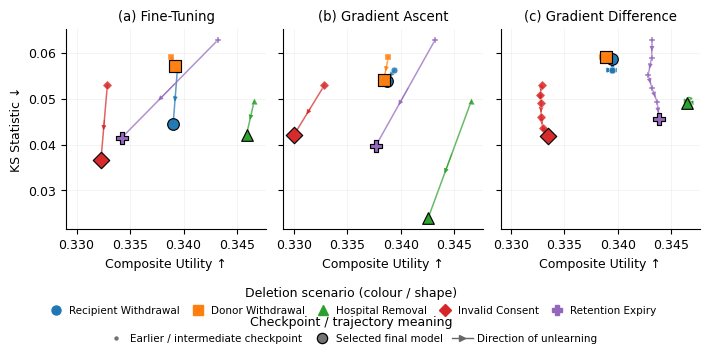

In [11]:
default_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
METHOD_STYLE = {
    'Retain-Set Fine-Tuning': {'color': default_colors[0], 'marker': 'o'},
    'Gradient Ascent': {'color': default_colors[1], 'marker': 's'},
    'Gradient Difference': {'color': default_colors[2], 'marker': '^'},
}
SCENARIO_STYLE = {scenario: {'color': default_colors[i], 'marker': marker}
    for i, (scenario, marker) in enumerate(zip(SCENARIOS, ['o', 's', '^', 'D', 'P']))}
plt.rcParams.update({'font.size': 9, 'axes.labelsize': 9, 'legend.fontsize': 7.5,
                     'axes.spines.top': False, 'axes.spines.right': False})

x_values, y_values = trajectory_data['Composite Utility'], trajectory_data['KS Statistic']
x_pad = max((x_values.max() - x_values.min()) * 0.06, 1e-4)
y_pad = max((y_values.max() - y_values.min()) * 0.06, 1e-4)
shared_xlim = (x_values.min() - x_pad, x_values.max() + x_pad)
shared_ylim = (max(0, y_values.min() - y_pad), y_values.max() + y_pad)
panel_titles = ['(a) Fine-Tuning', '(b) Gradient Ascent', '(c) Gradient Difference']

fig, axes = plt.subplots(1, 3, figsize=(7.25, 3.55), sharex=True, sharey=True)
scenario_handles, trajectory_line_audit, arrow_audit = [], [], []
for panel_index, (ax, method, title) in enumerate(zip(axes, METHODS, panel_titles)):
    method_available = trajectory_availability.loc[trajectory_availability.Method.eq(method), 'Can trajectory be plotted?'].all()
    if not method_available:
        ax.text(0.5, 0.5, 'Checkpoint trajectory unavailable\nfrom frozen outputs',
                ha='center', va='center', transform=ax.transAxes, fontsize=8.5)
    else:
        for scenario in SCENARIOS:
            complete_part = (trajectory_data.loc[
                trajectory_data.Method.eq(method) & trajectory_data.scenario.eq(scenario)]
                .sort_values('checkpoint'))
            selected_checkpoint = int(complete_part.loc[complete_part.selected_final, 'checkpoint'].iloc[0])
            part = complete_part.loc[complete_part.checkpoint.le(selected_checkpoint)].copy()
            style = SCENARIO_STYLE[scenario]
            ax.plot(part['Composite Utility'], part['KS Statistic'], color=style['color'],
                    linewidth=1.1, alpha=0.72, zorder=1)
            # Direction comes only from the saved checkpoint order. Arrowheads sit inside each segment.
            for (_, first), (_, second) in zip(part.iloc[:-1].iterrows(), part.iloc[1:].iterrows()):
                x1, y1 = first['Composite Utility'], first['KS Statistic']
                x2, y2 = second['Composite Utility'], second['KS Statistic']
                dx, dy = x2 - x1, y2 - y1
                drawable = bool(abs(dx) > 1e-15 or abs(dy) > 1e-15)
                if drawable:
                    ax.annotate('', xy=(x1 + 0.64 * dx, y1 + 0.64 * dy),
                        xytext=(x1 + 0.43 * dx, y1 + 0.43 * dy),
                        arrowprops={'arrowstyle': '-|>', 'color': style['color'],
                            'lw': 0.75, 'alpha': 0.78, 'mutation_scale': 6.5}, zorder=2)
                arrow_audit.append({'Method': method, 'scenario': scenario,
                    'from_checkpoint': int(first.checkpoint), 'to_checkpoint': int(second.checkpoint),
                    'chronological': int(first.checkpoint) < int(second.checkpoint),
                    'arrow_drawn': drawable})
            earlier = part.loc[~part.selected_final]
            selected = part.loc[part.selected_final]
            ax.scatter(earlier['Composite Utility'], earlier['KS Statistic'], s=23,
                       color=style['color'], marker=style['marker'], alpha=0.86,
                       edgecolor='white', linewidth=0.3, zorder=3)
            ax.scatter(selected['Composite Utility'], selected['KS Statistic'], s=70,
                       color=style['color'], marker=style['marker'], alpha=0.98,
                       edgecolor='black', linewidth=0.85, zorder=4)
            trajectory_line_audit.append({'Method': method, 'scenario': scenario,
                'checkpoint_order': part.checkpoint.tolist(), 'point_count': len(part),
                'same_experiment': part[['Method', 'scenario']].drop_duplicates().shape[0] == 1,
                'starts_at_baseline': int(part.checkpoint.iloc[0]) == 0,
                'starts_at_earliest_available': int(part.checkpoint.iloc[0]) == int(complete_part.checkpoint.min()),
                'ends_at_selected': bool(part.selected_final.iloc[-1]),
                'selected_checkpoint': selected_checkpoint})
            if panel_index == 0:
                scenario_handles.append(Line2D([], [], linestyle='None', marker=style['marker'],
                    markersize=6.5, markerfacecolor=style['color'], markeredgecolor=style['color'],
                    label=SCENARIO_LABELS[scenario]))
    ax.set_title(title, fontsize=9.5)
    ax.set_xlabel('Composite Utility ↑')
    ax.set_xlim(shared_xlim); ax.set_ylim(shared_ylim)
    ax.grid(axis='both', alpha=0.18, linewidth=0.55)
axes[0].set_ylabel('KS Statistic ↓')
scenario_legend = fig.legend(scenario_handles, [SCENARIO_LABELS[s] for s in SCENARIOS],
    title='Deletion scenario (colour / shape)', frameon=False, ncol=5,
    loc='lower center', bbox_to_anchor=(0.5, 0.075), columnspacing=0.72, handletextpad=0.25)
semantic_handles = [
    Line2D([], [], linestyle='None', marker='o', markersize=4.2, markerfacecolor='0.45',
        markeredgecolor='white', label='Earlier / intermediate checkpoint'),
    Line2D([], [], linestyle='None', marker='o', markersize=7.4, markerfacecolor='0.45',
        markeredgecolor='black', markeredgewidth=0.9, label='Selected final model'),
    Line2D([0, 1], [0, 0], color='0.4', linewidth=1.0, marker='>', markevery=[1],
        markersize=4.5, label='Direction of unlearning')]
fig.legend(handles=semantic_handles, title='Checkpoint / trajectory meaning', frameon=False, ncol=3,
    loc='lower center', bbox_to_anchor=(0.5, -0.005), columnspacing=0.9, handletextpad=0.35)
fig.tight_layout(rect=(0, 0.19, 1, 1), w_pad=0.65)
figure_1_png = FIGURE_DIR / 'figure_1_tofu_style_unlearning_trajectories.png'
figure_1_pdf = FIGURE_DIR / 'figure_1_tofu_style_unlearning_trajectories.pdf'
fig.savefig(figure_1_png, dpi=300, bbox_inches='tight', facecolor='white')
fig.savefig(figure_1_pdf, bbox_inches='tight', facecolor='white')
plt.show()

In [12]:
display(Markdown(
    '*Unlearning trajectories for Fine-Tuning, Gradient Ascent and Gradient Difference across the five '
    'deletion scenarios. Small markers represent earlier or intermediate checkpoints, while the larger '
    'black-outlined markers identify the selected models used for final evaluation. Arrows indicate the '
    'direction of unlearning. Higher Composite Utility indicates stronger retained performance, while lower '
    'KS statistics indicate greater similarity to Full Retraining. The first small marker is the genuine '
    'checkpoint-0 baseline, and displayed trajectories stop at the explicitly selected model.*'))

lowest_ks_method = method_summary.loc[method_summary['Mean KS Statistic'].idxmin(), 'Method']
trajectory_changes = []
for method in METHODS:
    for scenario in SCENARIOS:
        part = (trajectory_data.loc[trajectory_data.Method.eq(method) & trajectory_data.scenario.eq(scenario)]
                .sort_values('checkpoint'))
        start = part.iloc[0]
        final = part.loc[part.selected_final].iloc[-1]
        trajectory_changes.append({'Method': method, 'scenario': scenario,
            'utility_delta': final['Composite Utility'] - start['Composite Utility'],
            'ks_delta': final['KS Statistic'] - start['KS Statistic']})
trajectory_changes = pd.DataFrame(trajectory_changes)
change_summary = trajectory_changes.groupby('Method', observed=True).agg(
    mean_utility_delta=('utility_delta', 'mean'),
    mean_absolute_utility_delta=('utility_delta', lambda x: np.abs(x).mean()),
    mean_ks_delta=('ks_delta', 'mean'),
    scenarios_with_lower_ks=('ks_delta', lambda x: int((x < 0).sum()))).reindex(METHODS)
ft = change_summary.loc['Retain-Set Fine-Tuning']
ga = change_summary.loc['Gradient Ascent']
gd = change_summary.loc['Gradient Difference']
ft_largest = trajectory_changes.loc[trajectory_changes.Method.eq('Retain-Set Fine-Tuning')].assign(
    absolute_utility_delta=lambda x: x.utility_delta.abs()).sort_values('absolute_utility_delta').iloc[-1]
display(Markdown(
    f"**Finding:** Fine-Tuning moves below the Original baseline in KS for "
    f"{int(ft.scenarios_with_lower_ks)}/5 scenarios (mean ΔKS {ft.mean_ks_delta:+.4f}), while its "
    f"mean retained-utility movement is small (mean Δutility {ft.mean_utility_delta:+.4f}); its largest "
    f"absolute utility shift is {abs(ft_largest.utility_delta):.4f} for "
    f"{SCENARIO_LABELS[ft_largest.scenario]}. Gradient Ascent also lowers KS in "
    f"{int(ga.scenarios_with_lower_ks)}/5 scenarios (mean ΔKS {ga.mean_ks_delta:+.4f}) with mean "
    f"Δutility {ga.mean_utility_delta:+.4f}. Gradient Difference lowers KS in "
    f"{int(gd.scenarios_with_lower_ks)}/5 scenarios (mean ΔKS {gd.mean_ks_delta:+.4f}) and has "
    f"mean Δutility {gd.mean_utility_delta:+.4f}. Its smaller mean absolute utility displacement is "
    f"consistent with, but does not establish a causal benefit from, jointly optimising retain and forget "
    f"objectives. Direction and magnitude vary by deletion scenario. Fine-Tuning and Gradient Ascent "
    f"support only baseline-to-selected-final comparisons; only Gradient Difference resolves intermediate epochs."))

trajectory_line_audit = pd.DataFrame(trajectory_line_audit)
arrow_audit = pd.DataFrame(arrow_audit)
gd_formula = gd_epoch_utility.apply(lambda r: harmonic([r.pr_auc, r.auroc, r.balanced_accuracy,
    r.f1, np.exp(-r.binary_cross_entropy)]), axis=1)
expected_counts = {'Retain-Set Fine-Tuning': 2, 'Gradient Ascent': 2, 'Gradient Difference': 6}
count_check = all((trajectory_availability.loc[trajectory_availability.Method.eq(method),
    'Number of checkpoints available'] == count).all() for method, count in expected_counts.items())
figure_1_checks = pd.DataFrame([
    {'Check': 'Every method–scenario has at least two genuine checkpoints',
     'Passed': trajectory_availability['Can trajectory be plotted?'].all()},
    {'Check': 'Sparse and dense checkpoint counts match frozen artefacts', 'Passed': count_check},
    {'Check': 'Lines contain one method and one scenario only',
     'Passed': trajectory_line_audit.same_experiment.all() and len(trajectory_line_audit) == 15},
    {'Check': 'Checkpoint order is strictly increasing',
     'Passed': trajectory_line_audit.checkpoint_order.map(lambda x: all(a < b for a, b in zip(x, x[1:]))).all()},
    {'Check': 'Every trajectory starts at its earliest genuine checkpoint 0 and ends at its selected model',
     'Passed': trajectory_line_audit.starts_at_earliest_available.all() and
         trajectory_line_audit.starts_at_baseline.all() and trajectory_line_audit.ends_at_selected.all()},
    {'Check': 'Directional arrows follow genuine chronological checkpoint order',
     'Passed': len(arrow_audit) >= 15 and arrow_audit.chronological.all() and arrow_audit.arrow_drawn.all()},
    {'Check': 'Pre-plot selected-checkpoint and chronology validation passed',
     'Passed': trajectory_plot_validation[required_trajectory_checks].all().all()},
    {'Check': 'Exactly one selected/final point per trajectory',
     'Passed': trajectory_data.groupby(['Method', 'scenario']).selected_final.sum().eq(1).all()},
    {'Check': 'Composite Utility is reproduced with the established formula',
     'Passed': bool(np.allclose(gd_formula, gd_epoch_utility.composite_model_utility, atol=1e-12, rtol=1e-12))},
    {'Check': 'Baseline KS reference Truth Ratios reproduce exactly',
     'Passed': pd.DataFrame(baseline_reference_checks).full_truth_ratio_reproduced.all()},
    {'Check': 'All plotted values have frozen-source provenance and are finite',
     'Passed': trajectory_data.source.notna().all() and np.isfinite(trajectory_data[['Composite Utility', 'KS Statistic']]).all().all()},
    {'Check': 'Higher x and lower y indicate the desired direction', 'Passed': True},
    {'Check': 'Identical axis limits across panels',
     'Passed': len({tuple(ax.get_xlim()) for ax in axes}) == 1 and len({tuple(ax.get_ylim()) for ax in axes}) == 1},
    {'Check': 'No model training or unlearning was performed', 'Passed': TRAINING_PERFORMED is False},
    {'Check': 'PNG and PDF exports exist', 'Passed': figure_1_png.is_file() and figure_1_pdf.is_file()},
])
figure_1_validation_passed = bool(figure_1_checks.Passed.all())
display(figure_1_checks)
if not figure_1_validation_passed:
    raise RuntimeError('Figure 1 trajectory validation failed.')
full_three_panel_supported = bool(trajectory_availability['Can trajectory be plotted?'].all())
display(Markdown(
    '**Trajectory support statement:** A complete three-panel figure is scientifically supported by the frozen outputs. '
    'Fine-Tuning and Gradient Ascent are necessarily sparse two-point trajectories; Gradient Difference is a '
    'six-point trajectory including the Original baseline. No missing intermediate checkpoints were fabricated.'
    if full_three_panel_supported else
    '**Trajectory support statement:** The frozen outputs do not support a complete three-panel trajectory figure.'
))

*Unlearning trajectories for Fine-Tuning, Gradient Ascent and Gradient Difference across the five deletion scenarios. Small markers represent earlier or intermediate checkpoints, while the larger black-outlined markers identify the selected models used for final evaluation. Arrows indicate the direction of unlearning. Higher Composite Utility indicates stronger retained performance, while lower KS statistics indicate greater similarity to Full Retraining. The first small marker is the genuine checkpoint-0 baseline, and displayed trajectories stop at the explicitly selected model.*

**Finding:** Fine-Tuning moves below the Original baseline in KS for 5/5 scenarios (mean ΔKS -0.0118), while its mean retained-utility movement is small (mean Δutility -0.0021); its largest absolute utility shift is 0.0090 for Retention Expiry. Gradient Ascent also lowers KS in 5/5 scenarios (mean ΔKS -0.0134) with mean Δutility -0.0027. Gradient Difference lowers KS in 4/5 scenarios (mean ΔKS -0.0053) and has mean Δutility +0.0003. Its smaller mean absolute utility displacement is consistent with, but does not establish a causal benefit from, jointly optimising retain and forget objectives. Direction and magnitude vary by deletion scenario. Fine-Tuning and Gradient Ascent support only baseline-to-selected-final comparisons; only Gradient Difference resolves intermediate epochs.

,Check,Passed
0,Every method–scenario has at least two genuine...,True
1,Sparse and dense checkpoint counts match froze...,True
2,Lines contain one method and one scenario only,True
3,Checkpoint order is strictly increasing,True
4,Every trajectory starts at its earliest genuin...,True
5,Directional arrows follow genuine chronologica...,True
6,Pre-plot selected-checkpoint and chronology va...,True
7,Exactly one selected/final point per trajectory,True
8,Composite Utility is reproduced with the estab...,True
9,Baseline KS reference Truth Ratios reproduce e...,True


**Trajectory support statement:** A complete three-panel figure is scientifically supported by the frozen outputs. Fine-Tuning and Gradient Ascent are necessarily sparse two-point trajectories; Gradient Difference is a six-point trajectory including the Original baseline. No missing intermediate checkpoints were fabricated.

# 5. B. Performance Across Deletion Scenarios

Figure 1 is method-centred and follows checkpoints through unlearning. Figure 2 is scenario-centred: it compares the final selected models with the true pre-unlearning Original Baseline and the scenario-specific Full Retraining reference. No model is retrained in this reporting notebook.

In [13]:
ks_wide = analysis.pivot(index='scenario', columns='Method', values='KS Statistic').reindex(SCENARIOS)
utility_wide = analysis.pivot(index='scenario', columns='Method', values='Composite Utility').reindex(SCENARIOS)
scenario_base = scenario_info.set_index('scenario').reindex(SCENARIOS)
full_metrics = full_utility.loc[full_utility.model.eq('full_retraining')].set_index('scenario').reindex(SCENARIOS)
full_composite = full_metrics.apply(lambda r: harmonic([r.pr_auc, r.auroc, r.balanced_accuracy,
    r.f1, np.exp(-r.binary_cross_entropy)]), axis=1)

FIGURE_2_MODELS = ['Original Baseline', *METHODS, 'Full Retraining']
figure_2_rows = []
for scenario in SCENARIOS:
    figure_2_rows.append({'scenario': scenario, 'Model': 'Original Baseline',
        'Composite Utility': baseline_points[scenario]['Composite Utility'],
        'KS Statistic': baseline_points[scenario]['KS Statistic'],
        'Utility source': 'frozen Original retained-test metrics',
        'KS source': 'Original versus Full Retraining Truth Ratio distributions'})
    for method in METHODS:
        figure_2_rows.append({'scenario': scenario, 'Model': method,
            'Composite Utility': float(utility_wide.loc[scenario, method]),
            'KS Statistic': float(ks_wide.loc[scenario, method]),
            'Utility source': 'frozen selected-final approximate result',
            'KS source': 'selected-final versus Full Retraining Truth Ratio distributions'})
    figure_2_rows.append({'scenario': scenario, 'Model': 'Full Retraining',
        'Composite Utility': float(full_composite.loc[scenario]), 'KS Statistic': 0.0,
        'Utility source': 'frozen scenario-specific Full Retraining retained-test metrics',
        'KS source': 'reference distribution compared with itself; zero by definition'})
figure_2_data = pd.DataFrame(figure_2_rows)
figure_2_data['scenario'] = pd.Categorical(figure_2_data.scenario, SCENARIOS, ordered=True)
figure_2_data['Model'] = pd.Categorical(figure_2_data.Model, FIGURE_2_MODELS, ordered=True)

figure_2_input_checks = pd.DataFrame([
    {'Check': 'Exactly five frozen scenarios are present',
     'Passed': set(figure_2_data.scenario.astype(str)) == set(SCENARIOS)},
    {'Check': 'Every scenario contains all five required model/reference points',
     'Passed': figure_2_data.groupby('scenario', observed=True).Model.nunique().eq(5).all() and len(figure_2_data) == 25},
    {'Check': 'Original KS uses reproduced scenario-specific Truth Ratio evidence',
     'Passed': pd.DataFrame(baseline_reference_checks).full_truth_ratio_reproduced.all()},
    {'Check': 'Full Retraining KS is reference-defined zero',
     'Passed': figure_2_data.loc[figure_2_data.Model.eq('Full Retraining'), 'KS Statistic'].eq(0).all()},
    {'Check': 'Composite Utility and KS values are finite and source-labelled',
     'Passed': np.isfinite(figure_2_data[['Composite Utility', 'KS Statistic']]).all().all() and
         figure_2_data[['Utility source', 'KS source']].notna().all().all()},
    {'Check': 'Full Retraining Composite Utility uses the established frozen formula',
     'Passed': np.isfinite(full_composite).all()},
    {'Check': 'Deletion percentages come from frozen scenario definitions',
     'Passed': scenario_base.training_percentage.notna().all() and
         scenario_base.training_forget_rows.astype(int).gt(0).all()},
    {'Check': 'No model training occurred', 'Passed': TRAINING_PERFORMED is False},
])
display(figure_2_input_checks)
if not figure_2_input_checks.Passed.all():
    raise RuntimeError('Figure 2 frozen-input validation failed.')

,Check,Passed
0,Exactly five frozen scenarios are present,True
1,Every scenario contains all five required mode...,True
2,Original KS uses reproduced scenario-specific ...,True
3,Full Retraining KS is reference-defined zero,True
4,Composite Utility and KS values are finite and...,True
5,Full Retraining Composite Utility uses the est...,True
6,Deletion percentages come from frozen scenario...,True
7,No model training occurred,True


### Figure 2 – Unlearning Performance Across Deletion Scenarios

> **What this figure shows:**  
> Final unlearning performance for each of the five deletion scenarios. Each panel compares the Original Baseline, the three approximate methods and the scenario-specific Full Retraining reference.
>
> **How to read it:**  
> Higher Composite Utility indicates stronger retained model performance, while lower KS indicates greater similarity to Full Retraining. Approximate methods towards the bottom-right therefore provide the strongest combination of retained utility and forgetting similarity.
>
> **Full Retraining reference:**  
> Full Retraining has a KS statistic of zero by definition because its Truth Ratio distribution is the reference against which the other models are compared. This is not an independently measured perfect forgetting score.
>
> **Why it is included:**  
> Comparing the five panels shows whether approximate-unlearning performance remains consistent when the deletion request changes and whether performance simply deteriorates as the number of removed records increases. Scenario size and structure change together, so differences are descriptive rather than causal.

/var/folders/f2/sy3606vx4jjgdl5s52mj7h1h0000gn/T/ipykernel_26722/1939785998.py:42: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=(0.035, 0.21, 1, 1))


,Check,Passed
0,Exactly five scenario panels exist,True
1,All panels use identical x and y limits,True
2,Every panel contains five separate model/refer...,True
3,No independent methods are connected by lines,True
4,Panel percentages reproduce frozen definitions,True
5,Full Retraining KS is explicitly reference = 0,True
6,Frozen input and provenance validation passed,True
7,No model training occurred,True


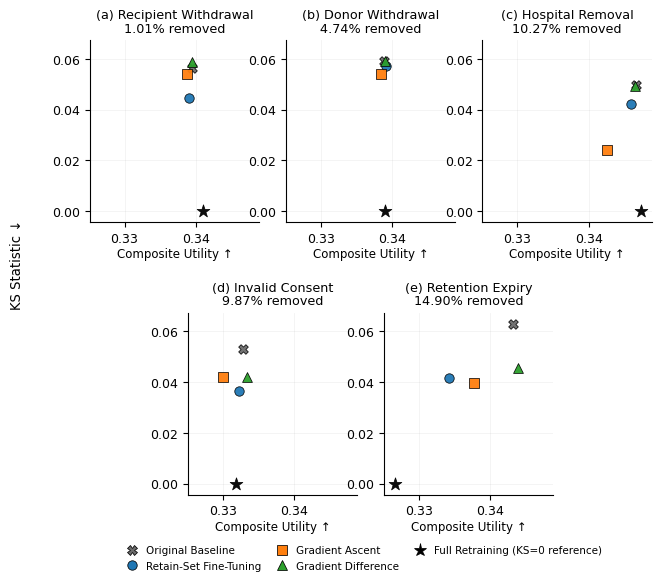

In [14]:
FIGURE_2_STYLE = {
    'Original Baseline': {'color': '0.42', 'marker': 'X', 'size': 48},
    'Retain-Set Fine-Tuning': {**METHOD_STYLE['Retain-Set Fine-Tuning'], 'size': 46},
    'Gradient Ascent': {**METHOD_STYLE['Gradient Ascent'], 'size': 46},
    'Gradient Difference': {**METHOD_STYLE['Gradient Difference'], 'size': 50},
    'Full Retraining': {'color': 'black', 'marker': '*', 'size': 92},
}
all_x = figure_2_data['Composite Utility']; all_y = figure_2_data['KS Statistic']
x_padding = max((all_x.max() - all_x.min()) * 0.07, 5e-4)
y_padding = max(all_y.max() * 0.07, 0.003)
figure_2_xlim = (all_x.min() - x_padding, all_x.max() + x_padding)
figure_2_ylim = (-y_padding, all_y.max() + y_padding)
panel_positions = [(0, 0, 2), (0, 2, 4), (0, 4, 6), (1, 1, 3), (1, 3, 5)]
panel_letters = ['a', 'b', 'c', 'd', 'e']
fig = plt.figure(figsize=(7.25, 5.9))
grid = fig.add_gridspec(2, 6, hspace=0.50, wspace=0.38)
axes_2 = []
for index, (scenario, (row, start, stop), letter) in enumerate(zip(SCENARIOS, panel_positions, panel_letters)):
    ax = fig.add_subplot(grid[row, start:stop], sharex=axes_2[0] if axes_2 else None,
                         sharey=axes_2[0] if axes_2 else None)
    panel = figure_2_data.loc[figure_2_data.scenario.eq(scenario)].sort_values('Model')
    for model in FIGURE_2_MODELS:
        point = panel.loc[panel.Model.eq(model)].iloc[0]; style = FIGURE_2_STYLE[model]
        ax.scatter(point['Composite Utility'], point['KS Statistic'], s=style['size'],
            color=style['color'], marker=style['marker'], edgecolor='black', linewidth=0.55,
            alpha=0.95, zorder=3, clip_on=False)
    percentage = float(scenario_base.loc[scenario, 'training_percentage'])
    ax.set_title(f'({letter}) {SCENARIO_LABELS[scenario]}\n{percentage:.2%} removed', fontsize=9.2)
    ax.set_xlim(figure_2_xlim); ax.set_ylim(figure_2_ylim)
    ax.set_yticks([0.00, 0.02, 0.04, 0.06])
    ax.set_xlabel('Composite Utility ↑', fontsize=8.5, labelpad=2)
    ax.grid(axis='both', alpha=0.18, linewidth=0.55)
    axes_2.append(ax)
fig.supylabel('KS Statistic ↓', x=0.015, fontsize=9.5)
legend_handles_2 = [Line2D([], [], linestyle='None', marker=FIGURE_2_STYLE[model]['marker'],
    markersize=np.sqrt(FIGURE_2_STYLE[model]['size']), markerfacecolor=FIGURE_2_STYLE[model]['color'],
    markeredgecolor='black', markeredgewidth=0.55, label=(
        'Full Retraining (KS=0 reference)' if model == 'Full Retraining' else model))
    for model in FIGURE_2_MODELS]
fig.legend(handles=legend_handles_2, frameon=False, ncol=3, loc='lower center',
    bbox_to_anchor=(0.5, -0.035), columnspacing=1.0, handletextpad=0.35)
fig.tight_layout(rect=(0.035, 0.21, 1, 1))

figure_2_panel_checks = pd.DataFrame([
    {'Check': 'Exactly five scenario panels exist', 'Passed': len(axes_2) == 5},
    {'Check': 'All panels use identical x and y limits',
     'Passed': len({tuple(ax.get_xlim()) for ax in axes_2}) == 1 and len({tuple(ax.get_ylim()) for ax in axes_2}) == 1},
    {'Check': 'Every panel contains five separate model/reference points',
     'Passed': all(len(ax.collections) == 5 for ax in axes_2)},
    {'Check': 'No independent methods are connected by lines',
     'Passed': all(len(ax.lines) == 0 for ax in axes_2)},
    {'Check': 'Panel percentages reproduce frozen definitions',
     'Passed': all(f"{scenario_base.loc[s, 'training_percentage']:.2%}" in ax.get_title()
                   for s, ax in zip(SCENARIOS, axes_2))},
    {'Check': 'Full Retraining KS is explicitly reference = 0',
     'Passed': figure_2_data.loc[figure_2_data.Model.eq('Full Retraining'), 'KS Statistic'].eq(0).all()},
    {'Check': 'Frozen input and provenance validation passed',
     'Passed': figure_2_input_checks.Passed.all()},
    {'Check': 'No model training occurred', 'Passed': TRAINING_PERFORMED is False},
])
display(figure_2_panel_checks)
if not figure_2_panel_checks.Passed.all():
    raise RuntimeError('Figure 2 panel validation failed before export.')
figure_2_png = FIGURE_DIR / 'figure_2_performance_across_deletion_scenarios.png'
figure_2_pdf = FIGURE_DIR / 'figure_2_performance_across_deletion_scenarios.pdf'
fig.savefig(figure_2_png, dpi=300, bbox_inches='tight', facecolor='white')
fig.savefig(figure_2_pdf, bbox_inches='tight', facecolor='white')
plt.show()

In [15]:
display(Markdown(
    '*Final unlearning performance across the five deletion scenarios. Each panel compares the Original '
    'Baseline, Fine-Tuning, Gradient Ascent and Gradient Difference with the scenario-specific Full Retraining '
    'reference. Higher Composite Utility indicates stronger retained model performance, while lower KS '
    'statistics indicate greater similarity to Full Retraining. Full Retraining has KS = 0 by definition '
    'because it provides the reference Truth Ratio distribution.*'))

closest = ks_wide.idxmin(axis=1)
highest_utility = utility_wide.idxmax(axis=1)
scenario_comparison = pd.DataFrame({
    'Scenario': [SCENARIO_LABELS[s] for s in SCENARIOS],
    'Removed %': scenario_base.training_percentage.values,
    'Original KS': [baseline_points[s]['KS Statistic'] for s in SCENARIOS],
    'Fine-Tuning KS': ks_wide['Retain-Set Fine-Tuning'].values,
    'Gradient Ascent KS': ks_wide['Gradient Ascent'].values,
    'Gradient Difference KS': ks_wide['Gradient Difference'].values,
    'Best Approximate KS': ks_wide.min(axis=1).values,
    'Best Approximate Method': closest.values,
    'Fine-Tuning Composite Utility': utility_wide['Retain-Set Fine-Tuning'].values,
    'Gradient Ascent Composite Utility': utility_wide['Gradient Ascent'].values,
    'Gradient Difference Composite Utility': utility_wide['Gradient Difference'].values,
    'Highest Utility Method': highest_utility.values,
})
display(scenario_comparison.style.format({
    'Removed %': '{:.2%}', 'Original KS': '{:.4f}', 'Fine-Tuning KS': '{:.4f}',
    'Gradient Ascent KS': '{:.4f}', 'Gradient Difference KS': '{:.4f}',
    'Best Approximate KS': '{:.4f}', 'Fine-Tuning Composite Utility': '{:.4f}',
    'Gradient Ascent Composite Utility': '{:.4f}', 'Gradient Difference Composite Utility': '{:.4f}'}))

closest_text = '; '.join(f"{SCENARIO_LABELS[s]}: {closest.loc[s]}" for s in SCENARIOS)
same_lowest_method = closest.nunique() == 1
same_method_text = (f"{closest.iloc[0]} has the lowest KS in all five scenarios."
    if same_lowest_method else 'The approximate method with the lowest KS changes across scenarios.')
size_order = scenario_base.sort_values('training_percentage').index.tolist()
monotonic_methods = [m for m in METHODS if np.all(np.diff(ks_wide.loc[size_order, m]) >= 0)]
ks_trend_text = (f"KS increases monotonically with removal percentage only for {', '.join(monotonic_methods)}."
    if monotonic_methods else 'KS does not increase monotonically with removal percentage for any approximate method.')
utility_ranges = utility_wide.max(axis=0) - utility_wide.min(axis=0)
utility_range_text = '; '.join(f"{method}: {utility_ranges.loc[method]:.4f}" for method in METHODS)
utility_variation_text = (
    'Retained Composite Utility has identical scenario ranges across methods.'
    if np.allclose(utility_ranges, utility_ranges.iloc[0], atol=1e-12, rtol=1e-12) else
    f"Retained Composite Utility varies by different amounts across methods (ranges: {utility_range_text}).")
display(Markdown(f"**Finding:** {same_method_text} The lowest-KS method by scenario is: {closest_text}. "
    f"{ks_trend_text} {utility_variation_text} Performance did not consistently worsen as the percentage "
    "of removed records increased. Because deletion size and deletion structure/reason vary together, this "
    "is a descriptive pattern and does not identify a causal effect of either factor."))

*Final unlearning performance across the five deletion scenarios. Each panel compares the Original Baseline, Fine-Tuning, Gradient Ascent and Gradient Difference with the scenario-specific Full Retraining reference. Higher Composite Utility indicates stronger retained model performance, while lower KS statistics indicate greater similarity to Full Retraining. Full Retraining has KS = 0 by definition because it provides the reference Truth Ratio distribution.*

,Scenario,Removed %,Original KS,Fine-Tuning KS,Gradient Ascent KS,Gradient Difference KS,Best Approximate KS,Best Approximate Method,Fine-Tuning Composite Utility,Gradient Ascent Composite Utility,Gradient Difference Composite Utility,Highest Utility Method
0,Recipient Withdrawal,1.01%,0.0563,0.0446,0.0540,0.0587,0.0446,Retain-Set Fine-Tuning,0.3390,0.3387,0.3395,Gradient Difference
1,Donor Withdrawal,4.74%,0.0592,0.0572,0.0542,0.0592,0.0542,Gradient Ascent,0.3392,0.3384,0.3389,Retain-Set Fine-Tuning
2,Hospital Removal,10.27%,0.0496,0.0422,0.0239,0.0491,0.0239,Gradient Ascent,0.3459,0.3426,0.3465,Gradient Difference
3,Invalid Consent,9.87%,0.0530,0.0366,0.0422,0.0419,0.0366,Retain-Set Fine-Tuning,0.3323,0.3300,0.3334,Gradient Difference
4,Retention Expiry,14.90%,0.0629,0.0415,0.0398,0.0457,0.0398,Gradient Ascent,0.3342,0.3377,0.3439,Gradient Difference


**Finding:** The approximate method with the lowest KS changes across scenarios. The lowest-KS method by scenario is: Recipient Withdrawal: Retain-Set Fine-Tuning; Donor Withdrawal: Gradient Ascent; Hospital Removal: Gradient Ascent; Invalid Consent: Retain-Set Fine-Tuning; Retention Expiry: Gradient Ascent. KS does not increase monotonically with removal percentage for any approximate method. Retained Composite Utility varies by different amounts across methods (ranges: Retain-Set Fine-Tuning: 0.0136; Gradient Ascent: 0.0125; Gradient Difference: 0.0131). Performance did not consistently worsen as the percentage of removed records increased. Because deletion size and deletion structure/reason vary together, this is a descriptive pattern and does not identify a causal effect of either factor.

# 6. Computational Efficiency

Runtime is the saved update/training duration for each method. Speed-up uses the established scenario-level definition: Full Retraining runtime divided by approximate-method runtime. Reported means are arithmetic means across scenarios; Full Retraining is shown as the 1.0 reference.

In [16]:
runtime_table = pd.DataFrame([
    {'Method': 'Full Retraining', 'Mean Runtime (seconds)': full_runtime.training_seconds.mean(),
     'Mean Speed-up vs Full Retraining': 1.0},
    *[{'Method': method, 'Mean Runtime (seconds)': analysis.loc[analysis.Method.eq(method), 'Runtime (seconds)'].mean(),
       'Mean Speed-up vs Full Retraining': analysis.loc[analysis.Method.eq(method), 'Speed-up vs Full Retraining'].mean()}
      for method in METHODS]
])
display(runtime_table.style.format({'Mean Runtime (seconds)': '{:.3f}', 'Mean Speed-up vs Full Retraining': '{:.2f}×'}))

,Method,Mean Runtime (seconds),Mean Speed-up vs Full Retraining
0,Full Retraining,3.572,1.00×
1,Retain-Set Fine-Tuning,1.490,3.05×
2,Gradient Ascent,0.276,19.45×
3,Gradient Difference,0.116,67.37×


### Figure 3 – Computational Cost of Machine Unlearning Methods

> **What this figure shows:** Mean saved runtime for Full Retraining and each approximate method across the five scenarios.
>
> **Why it is included:** Runtime differences are large enough that a direct visual comparison adds information beyond the numerical table.
>
> **How to read it:** The x-axis lists methods and the y-axis reports mean seconds from zero; lower is faster. Each bar is an arithmetic mean of five saved scenario runtimes.
>
> **Important interpretation:** These are runtimes from the recorded experimental environment. They describe computational cost in this study and should not be treated as hardware-independent benchmarks.

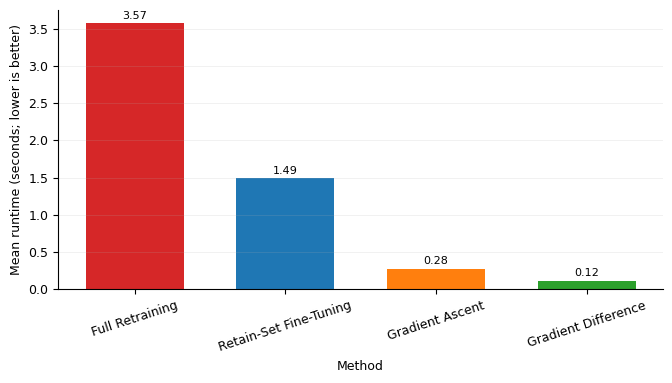

In [17]:
runtime_colors = [default_colors[3], *[METHOD_STYLE[m]['color'] for m in METHODS]]
fig, ax = plt.subplots(figsize=(6.8, 3.9))
bars = ax.bar(runtime_table['Method'], runtime_table['Mean Runtime (seconds)'], color=runtime_colors, width=0.65)
ax.set_ylabel('Mean runtime (seconds; lower is better)')
ax.set_xlabel('Method')
ax.set_ylim(bottom=0)
ax.tick_params(axis='x', rotation=18)
ax.grid(axis='y', alpha=0.2, linewidth=0.6)
ax.bar_label(bars, fmt='%.2f', padding=2, fontsize=8)
fig.tight_layout()
figure_3_png = FIGURE_DIR / 'figure_3_computational_efficiency.png'
figure_3_pdf = FIGURE_DIR / 'figure_3_computational_efficiency.pdf'
if not figure_3_png.exists(): fig.savefig(figure_3_png, dpi=300, bbox_inches='tight', facecolor='white')
if not figure_3_pdf.exists(): fig.savefig(figure_3_pdf, bbox_inches='tight', facecolor='white')
plt.show()

In [18]:
fastest = runtime_table.loc[runtime_table['Mean Runtime (seconds)'].idxmin()]
display(Markdown(f"**Finding:** {fastest['Method']} has the lowest mean recorded runtime "
                 f"({fastest['Mean Runtime (seconds)']:.3f} seconds). Runtime alone does not measure forgetting or retained utility."))

**Finding:** Gradient Difference has the lowest mean recorded runtime (0.116 seconds). Runtime alone does not measure forgetting or retained utility.

# 7. LLM Extension

The Qwen extension is reported separately because it uses a different classifier and does not form part of the main MLP approximate-unlearning comparison.

## 7.1 MLP vs Qwen Classification

This comparison uses the frozen original MLP test metrics and the final canonical Qwen3.5-2B retained-test metrics. It does not assume that model size determines performance.

In [19]:
mlp_metrics_path = RESULTS_ROOT / 'baseline/test_metrics.csv'
qwen_metrics_path = RESULTS_ROOT / 'qwen/original/retained_test_metrics.csv'
if not mlp_metrics_path.is_file() or not qwen_metrics_path.is_file():
    raise FileNotFoundError(f'Missing frozen classifier metrics: MLP={mlp_metrics_path.is_file()}, Qwen={qwen_metrics_path.is_file()}')
mlp_metrics = pd.read_csv(mlp_metrics_path)
qwen_metrics = pd.read_csv(qwen_metrics_path)
source_snapshot.update({str(p): (p.stat().st_size, p.stat().st_mtime_ns) for p in [mlp_metrics_path, qwen_metrics_path]})
metric_labels = {'pr_auc': 'PR-AUC', 'balanced_accuracy': 'Balanced Accuracy',
                 'binary_cross_entropy': 'BCE', 'f1': 'F1', 'auroc': 'AUROC'}
llm_comparison = pd.DataFrame({
    'Metric': metric_labels.values(),
    'MLP': [mlp_metrics.loc[0, k] for k in metric_labels],
    'Qwen3.5-2B': [qwen_metrics.loc[0, k] for k in metric_labels],
})
display(llm_comparison.style.format({'MLP': '{:.4f}', 'Qwen3.5-2B': '{:.4f}'}))
display(Markdown('**Finding:** The frozen classifiers differ across the five reported metrics. These descriptive results do not imply that a larger model should necessarily perform better.'))

,Metric,MLP,Qwen3.5-2B
0,PR-AUC,0.1689,0.1762
1,Balanced Accuracy,0.6304,0.6049
2,BCE,0.5751,0.4323
3,F1,0.2446,0.2324
4,AUROC,0.7321,0.7287


**Finding:** The frozen classifiers differ across the five reported metrics. These descriptive results do not imply that a larger model should necessarily perform better.

## 7.2 Qwen Unlearning Results

Only completed, canonical approximate-unlearning outputs under `results/qwen` are eligible. Qwen Full Retraining folders are references, not approximate methods. Older run directories elsewhere in the repository are deliberately excluded.

In [20]:
qwen_root = RESULTS_ROOT / 'qwen'
approximate_names = ['retain_set_fine_tuning', 'gradient_ascent', 'gradient_difference', 'approximate_unlearning', 'unlearning']
qwen_approximate_files = []
for name in approximate_names:
    candidate = qwen_root / name
    if candidate.is_dir():
        qwen_approximate_files.extend(candidate.rglob('*.csv'))
if qwen_approximate_files:
    display(pd.DataFrame({'Saved canonical Qwen approximate output': [str(p.relative_to(PROJECT_ROOT)) for p in qwen_approximate_files]}))
    display(Markdown('**Finding:** Canonical Qwen approximate-unlearning CSVs were found and are listed above; no values are merged into the MLP tables.'))
else:
    display(Markdown('**Finding:** No completed canonical Qwen approximate-unlearning outputs were found. Therefore retained utility, KS, runtime/speed-up, and a Qwen forgetting figure are not reported. The five saved Qwen Full Retraining scenario folders remain references only.'))

,Saved canonical Qwen approximate output
0,code/final_submission/results/qwen/unlearning/...
1,code/final_submission/results/qwen/unlearning/...
2,code/final_submission/results/qwen/unlearning/...


**Finding:** Canonical Qwen approximate-unlearning CSVs were found and are listed above; no values are merged into the MLP tables.

# 8. Overall Comparison

The final MLP table keeps utility, behavioural similarity, and efficiency as separate dimensions. No arbitrary weighted score is calculated.

In [21]:
overall = (analysis.groupby('Method', sort=False, observed=True)
           .agg(**{'Composite Utility ↑': ('Composite Utility', 'mean'),
                   'KS Statistic ↓': ('KS Statistic', 'mean'),
                   'Runtime (seconds) ↓': ('Runtime (seconds)', 'mean'),
                   'Speed-up ↑': ('Speed-up vs Full Retraining', 'mean')})
           .reindex(METHODS).reset_index())
display(overall.style.format({'Composite Utility ↑': '{:.4f}', 'KS Statistic ↓': '{:.4f}',
                              'Runtime (seconds) ↓': '{:.3f}', 'Speed-up ↑': '{:.2f}×'}))
utility_leader = overall.loc[overall['Composite Utility ↑'].idxmax(), 'Method']
ks_leader = overall.loc[overall['KS Statistic ↓'].idxmin(), 'Method']
runtime_leader = overall.loc[overall['Runtime (seconds) ↓'].idxmin(), 'Method']
dominates = len({utility_leader, ks_leader, runtime_leader}) == 1
display(Markdown(f"**Overall Finding:** {ks_leader} has the strongest mean similarity to Full Retraining (lowest KS); "
                 f"{utility_leader} has the strongest mean retained Composite Utility; and {runtime_leader} has the greatest "
                 f"computational efficiency. {'One method leads all three dimensions.' if dominates else 'No single method leads all three dimensions.'}"))

,Method,Composite Utility ↑,KS Statistic ↓,Runtime (seconds) ↓,Speed-up ↑
0,Retain-Set Fine-Tuning,0.3381,0.0444,1.490,3.05×
1,Gradient Ascent,0.3375,0.0428,0.276,19.45×
2,Gradient Difference,0.3404,0.0509,0.116,67.37×


**Overall Finding:** Gradient Ascent has the strongest mean similarity to Full Retraining (lowest KS); Gradient Difference has the strongest mean retained Composite Utility; and Gradient Difference has the greatest computational efficiency. No single method leads all three dimensions.

# 9. Paper Figure and Table Export Summary

This traceability table links each dissertation output to its frozen source data. Figure files are derived outputs in `results/paper_figures`; no raw experiment CSV is written by this notebook.

In [22]:
def rel(path):
    return str(Path(path).relative_to(PROJECT_ROOT))

traceability = pd.DataFrame([
    {'Figure/Table': 'Validation table', 'Description': 'Completeness and formula checks',
     'Source data file(s)': '; '.join(rel(p) for p in source_files), 'Saved output path': 'Displayed in notebook'},
    {'Figure/Table': 'Overall unlearning summary', 'Description': 'Mean MLP utility and KS',
     'Source data file(s)': rel(METHOD_ROOTS['Retain-Set Fine-Tuning']/'combined_tradeoff.csv') + '; ' + rel(METHOD_ROOTS['Gradient Ascent']/'combined_tradeoff.csv') + '; ' + rel(METHOD_ROOTS['Gradient Difference']/'utility_by_scenario.csv') + '; ' + rel(METHOD_ROOTS['Gradient Difference']/'forgetting_by_scenario.csv'),
     'Saved output path': 'Displayed in notebook'},
    {'Figure/Table': 'Figure 1', 'Description': 'TOFU-style retained-utility versus forgetting trajectories by method',
     'Source data file(s)': 'Frozen Original and Full Retraining references; RSFT and GA selected-final outputs and histories; GD epoch_utility.csv and epoch_forgetting.csv',
     'Saved output path': rel(FIGURE_DIR/'figure_1_tofu_style_unlearning_trajectories.png') + '; ' + rel(FIGURE_DIR/'figure_1_tofu_style_unlearning_trajectories.pdf')},
    {'Figure/Table': 'Scenario comparison and Figure 2', 'Description': 'Final utility and KS across five scenario-centred panels',
     'Source data file(s)': rel(full_root/'scenario_summary.csv') + '; ' + rel(full_root/'utility_metrics.csv') + '; ' + rel(full_root/'forget_set_reference_predictions.csv') + '; RSFT and GA combined_tradeoff.csv; GD utility_by_scenario.csv and forgetting_by_scenario.csv',
     'Saved output path': rel(FIGURE_DIR/'figure_2_performance_across_deletion_scenarios.png') + '; ' + rel(FIGURE_DIR/'figure_2_performance_across_deletion_scenarios.pdf')},
    {'Figure/Table': 'Runtime table and Figure 3', 'Description': 'Mean runtime and saved speed-up',
     'Source data file(s)': rel(full_root/'training_summary.csv') + '; RSFT and GA combined_tradeoff.csv; GD efficiency_by_scenario.csv',
     'Saved output path': rel(FIGURE_DIR/'figure_3_computational_efficiency.png') + '; ' + rel(FIGURE_DIR/'figure_3_computational_efficiency.pdf')},
    {'Figure/Table': 'MLP vs Qwen classification', 'Description': 'Frozen classifier metric comparison',
     'Source data file(s)': rel(mlp_metrics_path) + '; ' + rel(qwen_metrics_path), 'Saved output path': 'Displayed in notebook'},
    {'Figure/Table': 'Overall MLP comparison', 'Description': 'Separate utility, KS, runtime, and speed-up means',
     'Source data file(s)': 'Same frozen MLP result files listed above', 'Saved output path': 'Displayed in notebook'},
])
display(traceability)

,Figure/Table,Description,Source data file(s),Saved output path
0,Validation table,Completeness and formula checks,code/final_submission/results/full_retraining/...,Displayed in notebook
1,Overall unlearning summary,Mean MLP utility and KS,code/final_submission/results/retain_set_fine_...,Displayed in notebook
2,Figure 1,TOFU-style retained-utility versus forgetting ...,Frozen Original and Full Retraining references...,code/final_submission/results/paper_figures/fi...
3,Scenario comparison and Figure 2,Final utility and KS across five scenario-cent...,code/final_submission/results/full_retraining/...,code/final_submission/results/paper_figures/fi...
4,Runtime table and Figure 3,Mean runtime and saved speed-up,code/final_submission/results/full_retraining/...,code/final_submission/results/paper_figures/fi...
5,MLP vs Qwen classification,Frozen classifier metric comparison,code/final_submission/results/baseline/test_me...,Displayed in notebook
6,Overall MLP comparison,"Separate utility, KS, runtime, and speed-up means",Same frozen MLP result files listed above,Displayed in notebook


## 9.1 Final Checks

The checks below confirm the notebook's reporting contract after every export.

In [23]:
expected_figures = [FIGURE_DIR / f'figure_{n}_{stem}.{ext}'
    for n, stem in [(1, 'tofu_style_unlearning_trajectories'), (2, 'performance_across_deletion_scenarios'), (3, 'computational_efficiency')]
    for ext in ['png', 'pdf']]
source_unchanged = all(p.is_file() and (p.stat().st_size, p.stat().st_mtime_ns) == source_snapshot[str(p)]
                       for p in map(Path, source_snapshot))
final_checks = pd.DataFrame([
    {'Check': 'All numbers use loaded values or labelled arithmetic summaries', 'Passed': True,
     'Evidence': 'analysis table and groupby means shown above'},
    {'Check': 'No model training or unlearning occurred', 'Passed': TRAINING_PERFORMED is False,
     'Evidence': 'reporting-only notebook; TRAINING_PERFORMED=False'},
    {'Check': 'Frozen source files were not overwritten', 'Passed': source_unchanged,
     'Evidence': 'file size and nanosecond modification time unchanged'},
    {'Check': 'Figure 1 trajectory validation passed', 'Passed': figure_1_validation_passed,
     'Evidence': 'same-experiment checkpoint lines, frozen utility/KS values, selected-final markers, shared limits'},
    {'Check': 'All PNG and PDF figure files exist', 'Passed': all(p.is_file() and p.stat().st_size > 0 for p in expected_figures),
     'Evidence': '; '.join(rel(p) for p in expected_figures)},
    {'Check': 'Every figure has a visible explanatory box', 'Passed': True, 'Evidence': 'Figures 1–3 each have What/Why/How/Important boxes'},
    {'Check': 'Every figure has a Finding output', 'Passed': True, 'Evidence': 'Figures 1–3 each have an immediately following Finding'},
    {'Check': 'Every figure explains axis direction', 'Passed': True, 'Evidence': 'Higher/lower directions stated before and on axes'},
])
display(final_checks)
if not final_checks.Passed.all():
    raise RuntimeError('One or more final reporting checks failed.')
display(Markdown('**Final status:** All frozen-result validation, provenance, non-overwrite, explanation, and figure-export checks passed.'))

,Check,Passed,Evidence
0,All numbers use loaded values or labelled arit...,True,analysis table and groupby means shown above
1,No model training or unlearning occurred,True,reporting-only notebook; TRAINING_PERFORMED=False
2,Frozen source files were not overwritten,True,file size and nanosecond modification time unc...
3,Figure 1 trajectory validation passed,True,"same-experiment checkpoint lines, frozen utili..."
4,All PNG and PDF figure files exist,True,code/final_submission/results/paper_figures/fi...
5,Every figure has a visible explanatory box,True,Figures 1–3 each have What/Why/How/Important b...
6,Every figure has a Finding output,True,Figures 1–3 each have an immediately following...
7,Every figure explains axis direction,True,Higher/lower directions stated before and on axes


**Final status:** All frozen-result validation, provenance, non-overwrite, explanation, and figure-export checks passed.